# Looking over all findings:

These were the report finding for the model first train:

## Setup

Import standard libraries and set the working directory to the project root.

In [1]:
import sys
from pathlib import Path



In [2]:
import os
os.chdir("..")

Load core dependencies — pandas for data handling, joblib for model loading, and scikit-learn metrics for evaluation. Custom config paths (`X_VALID`, `Y_VALID`, `MODEL_PATH`) point to the pre-split validation data and the saved model artifact.

In [3]:
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from config.settings import X_VALID, Y_VALID, MODEL_PATH

## Looking at the (1) Model statistics:

Load the validation features and labels, convert labels to binary (0 = BENIGN, 1 = ATTACK), then run the original model's predictions and print the confusion matrix and classification report.

In [4]:
def convert_to_binary(y_series):
    return y_series.apply(lambda x: 0 if x == "BENIGN" else 1)


print("Loading validation dataset...")

X_valid = pd.read_parquet(X_VALID)
y_valid = pd.read_parquet(Y_VALID)["Label"]

y_valid_binary = convert_to_binary(y_valid)

print("Loading trained model...")
model = joblib.load(MODEL_PATH)

print("Running predictions...")
y_pred = model.predict(X_valid)

print("\nConfusion Matrix")
print(confusion_matrix(y_valid_binary, y_pred))

print("\nClassification Report")
print(classification_report(y_valid_binary, y_pred, target_names=["BENIGN", "ATTACK"]))

Loading validation dataset...
Loading trained model...
Running predictions...

Confusion Matrix
[[456011    399]
 [  2182     34]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    456410
      ATTACK       0.08      0.02      0.03      2216

    accuracy                           0.99    458626
   macro avg       0.54      0.51      0.51    458626
weighted avg       0.99      0.99      0.99    458626



### If we represent the findings graphically using a heatmap, we can see that the model is skewed on detecting normal inflows of network traffic rather than on attacks.

Visualise the confusion matrix as a heatmap. If the model is skewed toward BENIGN, the off-diagonal attack cell will show a high false-negative count.

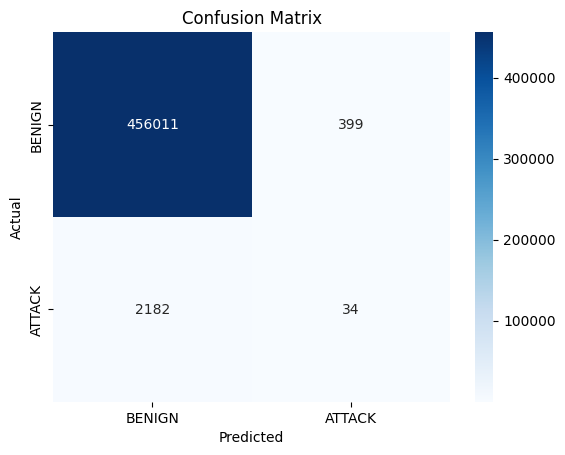

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid_binary, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["BENIGN", "ATTACK"],
            yticklabels=["BENIGN", "ATTACK"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

So , let's hyper tune our model. First, let's turn down the threshold for the data by changing the prediction method to a more probabilitalistic approach.

## Threshold Tuning

The default 0.5 threshold is too conservative here. Instead of predicting a hard class, `predict_proba` returns the probability of an attack. We can then pick a lower threshold to catch more attacks at the cost of more false positives.

In [6]:
y_probs = model.predict_proba(X_valid)[:, 1]
y_probs[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

Test threshold = 0.2 and print the resulting metrics. Lowering the threshold increases recall (fewer missed attacks) but may reduce precision.

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

threshold = 0.2
y_pred_thresh = (y_probs >= threshold).astype(int)

print(f"Threshold: {threshold}")
print("Accuracy :", accuracy_score(y_valid_binary, y_pred_thresh))
print("Precision:", precision_score(y_valid_binary, y_pred_thresh, zero_division=0))
print("Recall   :", recall_score(y_valid_binary, y_pred_thresh, zero_division=0))
print("F1 Score :", f1_score(y_valid_binary, y_pred_thresh, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid_binary, y_pred_thresh))

print("\nClassification Report")
print(classification_report(y_valid_binary, y_pred_thresh, target_names=["BENIGN", "ATTACK"], zero_division=0))

Threshold: 0.2
Accuracy : 0.9921984361985583
Precision: 0.19706405693950177
Recall   : 0.19990974729241878
F1 Score : 0.19847670250896057

Confusion Matrix
[[454605   1805]
 [  1773    443]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    456410
      ATTACK       0.20      0.20      0.20      2216

    accuracy                           0.99    458626
   macro avg       0.60      0.60      0.60    458626
weighted avg       0.99      0.99      0.99    458626



Sweep a range of thresholds (0.05 – 0.5) and print metrics for each to find a good operating point.

In [8]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]

for threshold in thresholds:
    y_pred_thresh = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_valid_binary, y_pred_thresh)
    prec = precision_score(y_valid_binary, y_pred_thresh, zero_division=0)
    rec = recall_score(y_valid_binary, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_valid_binary, y_pred_thresh, zero_division=0)

    print(f"\nThreshold = {threshold}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")


Threshold = 0.5
Accuracy : 0.9944
Precision: 0.0814
Recall   : 0.0162
F1 Score : 0.0271

Threshold = 0.4
Accuracy : 0.9938
Precision: 0.1048
Recall   : 0.0366
F1 Score : 0.0542

Threshold = 0.3
Accuracy : 0.9931
Precision: 0.1204
Recall   : 0.0695
F1 Score : 0.0881

Threshold = 0.2
Accuracy : 0.9922
Precision: 0.1971
Recall   : 0.1999
F1 Score : 0.1985

Threshold = 0.1
Accuracy : 0.9879
Precision: 0.2758
Recall   : 0.9210
F1 Score : 0.4245

Threshold = 0.05
Accuracy : 0.9438
Precision: 0.0777
Recall   : 0.9788
F1 Score : 0.1440


Plot all four metrics against the threshold range to visualise the precision–recall trade-off.

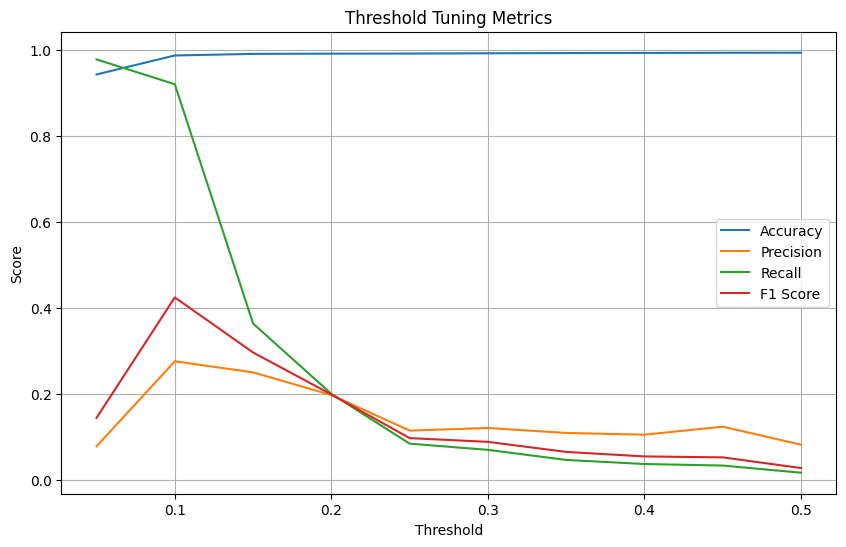

In [9]:
import matplotlib.pyplot as plt

thresholds = [i / 100 for i in range(5, 55, 5)]

accuracies = []
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred_thresh = (y_probs >= threshold).astype(int)

    accuracies.append(accuracy_score(y_valid_binary, y_pred_thresh))
    precisions.append(precision_score(y_valid_binary, y_pred_thresh, zero_division=0))
    recalls.append(recall_score(y_valid_binary, y_pred_thresh, zero_division=0))
    f1_scores.append(f1_score(y_valid_binary, y_pred_thresh, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracies, label="Accuracy")
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Metrics")
plt.legend()
plt.grid(True)
plt.show()

Lock in threshold = 0.1 as the candidate and evaluate it in full detail.

In [10]:
threshold = 0.1
y_pred_thresh = (y_probs >= threshold).astype(int)

print(f"Threshold: {threshold}")
print("Accuracy :", accuracy_score(y_valid_binary, y_pred_thresh))
print("Precision:", precision_score(y_valid_binary, y_pred_thresh, zero_division=0))
print("Recall   :", recall_score(y_valid_binary, y_pred_thresh, zero_division=0))
print("F1 Score :", f1_score(y_valid_binary, y_pred_thresh, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid_binary, y_pred_thresh))

print("\nClassification Report")
print(classification_report(y_valid_binary, y_pred_thresh, target_names=["BENIGN", "ATTACK"], zero_division=0))

Threshold: 0.1
Accuracy : 0.9879335231757467
Precision: 0.2758108108108108
Recall   : 0.921028880866426
F1 Score : 0.4245008319467554

Confusion Matrix
[[451051   5359]
 [   175   2041]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99    456410
      ATTACK       0.28      0.92      0.42      2216

    accuracy                           0.99    458626
   macro avg       0.64      0.95      0.71    458626
weighted avg       1.00      0.99      0.99    458626



### Let's try to get the precision score up. First let's do some feature engineering.

Inspect feature importances from the original model to understand which input signals are most predictive.

In [11]:
importances = pd.Series(model.feature_importances_, index=X_valid.columns)
importances.sort_values(ascending=False).head(20)

Destination Port               0.082254
Bwd Packets/s                  0.080424
Packet Length Std              0.066490
Avg Bwd Segment Size           0.054856
Max Packet Length              0.045886
Average Packet Size            0.045302
Bwd Packet Length Max          0.044128
Packet Length Variance         0.042357
Packet Length Mean             0.040281
Bwd Packet Length Std          0.038558
Init_Win_bytes_forward         0.028170
Bwd Packet Length Min          0.024347
Init_Win_bytes_backward        0.023235
Fwd Header Length.1            0.021113
Total Length of Bwd Packets    0.019130
Min Packet Length              0.018071
Fwd Packet Length Mean         0.017660
Subflow Bwd Bytes              0.015491
Bwd Header Length              0.014540
Fwd Header Length              0.014524
dtype: float64

Let's create a helper function to help test differing thresholds at a more efficient rate.

Define a helper `evaluate_threshold()` to keep threshold testing concise for subsequent experiments.

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_threshold(threshold):
    
    y_pred = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_valid_binary, y_pred)
    prec = precision_score(y_valid_binary, y_pred, zero_division=0)
    rec = recall_score(y_valid_binary, y_pred, zero_division=0)
    f1 = f1_score(y_valid_binary, y_pred, zero_division=0)

    print(f"\nThreshold: {threshold}")
    print("----------------------")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 Score :", round(f1,4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_valid_binary, y_pred))

Programmatically search 50 evenly-spaced thresholds between 0.01 and 0.5 and report the one that maximises F1.

In [13]:
import numpy as np

best_threshold = None
best_f1 = 0

for t in np.linspace(0.01,0.5,50):

    y_pred = (y_probs >= t).astype(int)
    f1 = f1_score(y_valid_binary, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.11
Best F1 Score: 0.4436635185591917


In [14]:
evaluate_threshold(0.11)


Threshold: 0.11
----------------------
Accuracy : 0.989
Precision: 0.2932
Recall   : 0.9116
F1 Score : 0.4437

Confusion Matrix
[[451540   4870]
 [   196   2020]]


## Model Retraining

Threshold tuning on the original model only goes so far. The next step is to retrain from scratch with explicit class balancing.

## Let's try retraining our model.

Import all required libraries and reload the train/validation data paths from config.

In [15]:
import pandas as pd
import joblib
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from config.settings import X_TRAIN, Y_TRAIN, X_VALID, Y_VALID

Read the training and validation parquet files and confirm shapes.

In [16]:
X_train = pd.read_parquet(X_TRAIN)
y_train = pd.read_parquet(Y_TRAIN)["Label"]

X_valid = pd.read_parquet(X_VALID)
y_valid = pd.read_parquet(Y_VALID)["Label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (1666532, 78)
y_train: (1666532,)
X_valid: (458626, 78)
y_valid: (458626,)


Convert multi-class labels to binary (BENIGN = 0, anything else = 1) and check class distribution.

In [17]:
def convert_to_binary(y_series):
    return y_series.apply(lambda x: 0 if x == "BENIGN" else 1)

y_train_binary = convert_to_binary(y_train)
y_valid_binary = convert_to_binary(y_valid)

print(y_train_binary.value_counts())
print(y_valid_binary.value_counts())

Label
0    1400977
1     265555
Name: count, dtype: int64
Label
0    456410
1      2216
Name: count, dtype: int64


Downsample to a manageable training subset: 100 000 BENIGN and 50 000 ATTACK samples, then shuffle. This balances the classes while keeping training fast.

In [18]:
train_df = X_train.copy()
train_df["Label"] = y_train_binary

benign = train_df[train_df["Label"] == 0]
attack = train_df[train_df["Label"] == 1]

benign_sample = benign.sample(n=100000, random_state=42)
attack_sample = attack.sample(n=50000, random_state=42)

train_sample = pd.concat([benign_sample, attack_sample]).sample(frac=1, random_state=42)

X_train_sample = train_sample.drop("Label", axis=1)
y_train_sample = train_sample["Label"]

print("Training sample shape:", X_train_sample.shape)
print(y_train_sample.value_counts())

Training sample shape: (150000, 78)
Label
0    100000
1     50000
Name: count, dtype: int64


Train a `RandomForestClassifier` with `class_weight="balanced"` on the downsampled data, then generate attack probabilities on the validation set using the tuned threshold of 0.11.

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_sample, y_train_sample)

y_probs = rf_model.predict_proba(X_valid)[:, 1]
y_pred = (y_probs >= 0.11).astype(int)

Evaluate the retrained model at threshold 0.11 with full metrics and confusion matrix.

In [20]:
y_probs = rf_model.predict_proba(X_valid)[:, 1]

threshold = 0.11
y_pred = (y_probs >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy :", accuracy_score(y_valid_binary, y_pred))
print("Precision:", precision_score(y_valid_binary, y_pred, zero_division=0))
print("Recall   :", recall_score(y_valid_binary, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_valid_binary, y_pred, zero_division=0))

print("\nConfusion Matrix")
cm = confusion_matrix(y_valid_binary, y_pred)
print(cm)

print("\nClassification Report")
print(classification_report(y_valid_binary, y_pred, target_names=["BENIGN", "ATTACK"], zero_division=0))

Threshold: 0.11
Accuracy : 0.9916773144130512
Precision: 0.2601138747377884
Recall   : 0.3916967509025271
F1 Score : 0.31262380695119757

Confusion Matrix
[[453941   2469]
 [  1348    868]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00    456410
      ATTACK       0.26      0.39      0.31      2216

    accuracy                           0.99    458626
   macro avg       0.63      0.69      0.65    458626
weighted avg       0.99      0.99      0.99    458626



Re-run the threshold sweep on the retrained model to see whether the new training improves the metric curves.

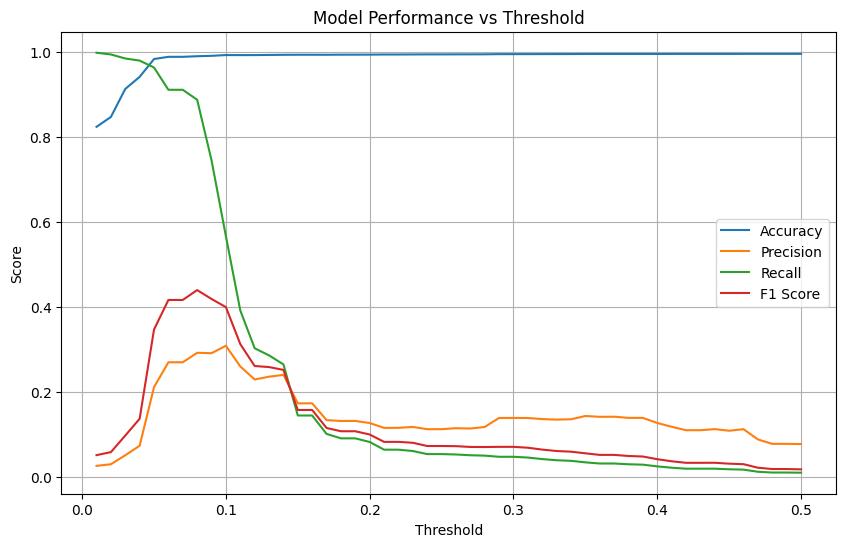

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.linspace(0.01, 0.5, 50)

accuracies = []
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)

    accuracies.append(accuracy_score(y_valid_binary, y_pred))
    precisions.append(precision_score(y_valid_binary, y_pred, zero_division=0))
    recalls.append(recall_score(y_valid_binary, y_pred, zero_division=0))
    f1_scores.append(f1_score(y_valid_binary, y_pred, zero_division=0))

plt.figure(figsize=(10,6))
plt.plot(thresholds, accuracies, label="Accuracy")
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Model Performance vs Threshold")
plt.legend()
plt.grid(True)

plt.show()

## Now, since performance goes up but not by much => let's try differing models to guage.

## Comparing Classifiers

Random Forest may not be the best choice. Train several standard classifiers on the same sample and compare their default-threshold performance.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    model.fit(X_train_sample, y_train_sample)
    
    y_pred = model.predict(X_valid)
    
    accuracy = accuracy_score(y_valid_binary, y_pred)
    precision = precision_score(y_valid_binary, y_pred, zero_division=0)
    recall = recall_score(y_valid_binary, y_pred, zero_division=0)
    f1 = f1_score(y_valid_binary, y_pred, zero_division=0)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

results_df

Training Logistic Regression...


c:\Users\Latre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training AdaBoost...
Training KNN...


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.994527,0.171875,0.034747,0.057808
1,AdaBoost,0.987872,0.030584,0.049188,0.037716
2,Gradient Boosting,0.992693,0.027477,0.014892,0.019315
3,Random Forest,0.994636,0.076389,0.009928,0.017572
4,KNN,0.908677,0.005756,0.104242,0.010910
5,Logistic Regression,0.882933,0.000660,0.015343,0.001265


Now let's find the best model:

Extend the comparison by also tuning the threshold per model — each model gets evaluated at 50 thresholds and its best F1 is recorded.

In [23]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

thresholds = np.arange(0.01, 0.51, 0.01)

results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")

    model.fit(X_train_sample, y_train_sample)

    if not hasattr(model, "predict_proba"):
        print(f"{model_name} skipped - no predict_proba")
        continue

    y_probs = model.predict_proba(X_valid)[:, 1]

    best_threshold = None
    best_accuracy = 0
    best_precision = 0
    best_recall = 0
    best_f1 = -1

    for threshold in thresholds:
        y_pred = (y_probs >= threshold).astype(int)

        accuracy = accuracy_score(y_valid_binary, y_pred)
        precision = precision_score(y_valid_binary, y_pred, zero_division=0)
        recall = recall_score(y_valid_binary, y_pred, zero_division=0)
        f1 = f1_score(y_valid_binary, y_pred, zero_division=0)

        if f1 > best_f1:
            best_threshold = threshold
            best_accuracy = accuracy
            best_precision = precision
            best_recall = recall
            best_f1 = f1

    results.append({
        "Model": model_name,
        "Best Threshold": best_threshold,
        "Accuracy": best_accuracy,
        "Precision": best_precision,
        "Recall": best_recall,
        "F1 Score": best_f1
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
results_df.round(4)

Training Logistic Regression...


c:\Users\Latre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training AdaBoost...
Training KNN...


,Model,Best Threshold,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.08,0.9891,0.2922,0.8867,0.4395
1,Gradient Boosting,0.12,0.9888,0.2887,0.8953,0.4366
2,AdaBoost,0.44,0.9608,0.1073,0.9711,0.1932
3,Decision Tree,0.01,0.9945,0.1719,0.0347,0.0578
4,KNN,0.01,0.8981,0.0070,0.1435,0.0134
5,Logistic Regression,0.16,0.2543,0.0061,0.9395,0.0120


Identify the top-performing model from the comparison table.

In [24]:
best_model_row = results_df.iloc[0]
best_model_row

Model             Random Forest
Best Threshold             0.08
Accuracy               0.989074
Precision              0.292193
Recall                 0.886733
F1 Score               0.439548
Name: 0, dtype: object

Retrain the best model and evaluate it with its optimal threshold, including a full classification report.

In [25]:
best_model_name = best_model_row["Model"]
best_threshold = best_model_row["Best Threshold"]

best_model = models[best_model_name]
best_model.fit(X_train_sample, y_train_sample)

y_probs = best_model.predict_proba(X_valid)[:, 1]
y_pred = (y_probs >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix")
print(confusion_matrix(y_valid_binary, y_pred))

print("\nClassification Report")
print(classification_report(y_valid_binary, y_pred, target_names=["BENIGN", "ATTACK"], zero_division=0))

Confusion Matrix
[[451650   4760]
 [   251   1965]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99    456410
      ATTACK       0.29      0.89      0.44      2216

    accuracy                           0.99    458626
   macro avg       0.65      0.94      0.72    458626
weighted avg       1.00      0.99      0.99    458626



Plot the ROC curve and compute AUC for the best model on the validation set.

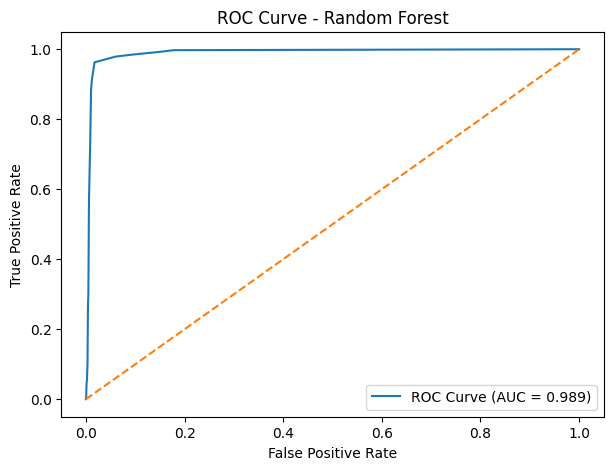

In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_valid_binary, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

## Time to test model on test set to see performance metrics.

## Final Evaluation on the Test Set

Define explicit file paths for train, validation, and test parquet files so the test evaluation is self-contained.

In [27]:
# File paths
X_TRAIN = "data/processed/X_train.parquet"
Y_TRAIN = "data/processed/y_train.parquet"

X_VALID = "data/processed/X_valid.parquet"
Y_VALID = "data/processed/y_valid.parquet"

X_TEST = "data/processed/X_test.parquet"
Y_TEST = "data/processed/y_test.parquet"

Load the held-out test set, apply the binary label conversion, run predictions at the chosen threshold, and print the confusion matrix and classification report. This is the first look at true generalisation performance.

In [28]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

print("Evaluating final model on TEST set...")

X_test = pd.read_parquet(X_TEST)
y_test = pd.read_parquet(Y_TEST)["Label"]

y_test_binary = y_test.apply(lambda x: 0 if x == "BENIGN" else 1)

y_test_probs = best_model.predict_proba(X_test)[:,1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test_binary, y_test_pred))

print("\nClassification Report")
print(classification_report(
    y_test_binary,
    y_test_pred,
    target_names=["BENIGN","ATTACK"],
    zero_division=0
))

Evaluating final model on TEST set...
Confusion Matrix
[[408651   5282]
 [155242 133543]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       0.72      0.99      0.84    413933
      ATTACK       0.96      0.46      0.62    288785

    accuracy                           0.77    702718
   macro avg       0.84      0.72      0.73    702718
weighted avg       0.82      0.77      0.75    702718



Check class proportions across all three splits to confirm the test set distribution matches train and validation.

In [29]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValid:")
print(y_valid.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Label
BENIGN              0.840654
DoS Hulk            0.138086
DoS GoldenEye       0.006176
FTP-Patator         0.004761
SSH-Patator         0.003538
DoS slowloris       0.003478
DoS Slowhttptest    0.003300
Heartbleed          0.000007
Name: proportion, dtype: float64

Valid:
Label
BENIGN                    0.995168
WebAttack_BruteForce      0.003286
WebAttack_XSS             0.001422
Infiltration              0.000078
WebAttack_SQLInjection    0.000046
Name: proportion, dtype: float64

Test:
Label
BENIGN      0.589046
PortScan    0.225985
DDoS        0.182185
Bot         0.002783
Name: proportion, dtype: float64


Run a final threshold sweep on the validation probabilities and tabulate the top 10 results.

In [30]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

for t in np.arange(0.01, 0.51, 0.01):
    y_pred = (y_probs >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_valid_binary, y_pred),
        "precision": precision_score(y_valid_binary, y_pred, zero_division=0),
        "recall": recall_score(y_valid_binary, y_pred, zero_division=0),
        "f1": f1_score(y_valid_binary, y_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results).sort_values("f1", ascending=False)
print(threshold_df.head(10))

    threshold  accuracy  precision    recall        f1
7        0.08  0.989074   0.292193  0.886733  0.439548
8        0.09  0.990009   0.291211  0.744585  0.418675
6        0.07  0.987670   0.269905  0.910199  0.416348
5        0.06  0.987668   0.269869  0.910199  0.416305
9        0.10  0.991780   0.308715  0.565884  0.399490
4        0.05  0.982482   0.211523  0.962545  0.346829
10       0.11  0.991677   0.260114  0.391697  0.312624
11       0.12  0.991719   0.229480  0.302798  0.261089
12       0.13  0.992076   0.236039  0.286101  0.258670
13       0.14  0.992401   0.240278  0.264892  0.251985


Explore a more regularised Random Forest configuration (deeper trees, more estimators) to see if it improves on the current best.

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [32]:
y_train = pd.read_parquet(Y_TRAIN)["Label"]
y_valid = pd.read_parquet(Y_VALID)["Label"]
y_test  = pd.read_parquet(Y_TEST)["Label"]

# Convert to binary
y_train_binary = (y_train != "BENIGN").astype(int)
y_valid_binary = (y_valid != "BENIGN").astype(int)
y_test_binary  = (y_test  != "BENIGN").astype(int)

Fit the deeper Random Forest on the downsampled training data.

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sample, y_train_sample)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

Sanity-check the binary class proportions across all three splits after the label re-conversion.

In [34]:
print("Train binary:")
print(y_train_binary.value_counts(normalize=True))

print("\nValid binary:")
print(y_valid_binary.value_counts(normalize=True))

print("\nTest binary:")
print(y_test_binary.value_counts(normalize=True))

Train binary:
Label
0    0.840654
1    0.159346
Name: proportion, dtype: float64

Valid binary:
Label
0    0.995168
1    0.004832
Name: proportion, dtype: float64

Test binary:
Label
0    0.589046
1    0.410954
Name: proportion, dtype: float64


In [35]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

print("Evaluating final model on TEST set...")

X_test = pd.read_parquet(X_TEST)
y_test = pd.read_parquet(Y_TEST)["Label"]

y_test_binary = y_test.apply(lambda x: 0 if x == "BENIGN" else 1)

y_test_probs = best_model.predict_proba(X_test)[:,1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test_binary, y_test_pred))

print("\nClassification Report")
print(classification_report(
    y_test_binary,
    y_test_pred,
    target_names=["BENIGN","ATTACK"],
    zero_division=0
))

Evaluating final model on TEST set...
Confusion Matrix
[[408651   5282]
 [155242 133543]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       0.72      0.99      0.84    413933
      ATTACK       0.96      0.46      0.62    288785

    accuracy                           0.77    702718
   macro avg       0.84      0.72      0.73    702718
weighted avg       0.82      0.77      0.75    702718



In [36]:
RandomForestClassifier(
    n_estimators=400,
    max_depth=25,
    class_weight={0:1,1:3},
    n_jobs=-1,
    random_state=42
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Sweep thresholds on the test set using the deeper Random Forest and rank by F1.

In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Get attack probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]

results = []

for threshold in np.arange(0.10, 0.95, 0.05):
    preds = (rf_probs >= threshold).astype(int)

    results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_test_binary, preds),
        "Precision": precision_score(y_test_binary, preds, zero_division=0),
        "Recall": recall_score(y_test_binary, preds, zero_division=0),
        "F1": f1_score(y_test_binary, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.sort_values("F1", ascending=False).head(10))

    Threshold  Accuracy  Precision    Recall        F1
0        0.10  0.766996   0.949070  0.457572  0.617454
1        0.15  0.760578   0.954333  0.438378  0.600783
2        0.20  0.713897   0.973849  0.312191  0.472811
3        0.25  0.704004   0.975177  0.287041  0.443529
4        0.30  0.703412   0.977789  0.284762  0.441071
5        0.35  0.703740   0.982796  0.284066  0.440741
6        0.40  0.703890   0.987944  0.282909  0.439860
9        0.55  0.704614   0.997160  0.282023  0.439690
8        0.50  0.704553   0.996489  0.282065  0.439675
10       0.60  0.704630   0.997525  0.281957  0.439646


Apply the best threshold to the test set and print the final confusion matrix and classification report.

In [38]:
best_threshold = threshold_df.sort_values("F1", ascending=False).iloc[0]["Threshold"]
print("Best threshold:", best_threshold)

best_preds = (rf_probs >= best_threshold).astype(int)

print("\nConfusion Matrix")
print(confusion_matrix(y_test_binary, best_preds))

print("\nClassification Report")
print(classification_report(y_test_binary, best_preds, target_names=["BENIGN", "ATTACK"]))

Best threshold: 0.1

Confusion Matrix
[[406842   7091]
 [156645 132140]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       0.72      0.98      0.83    413933
      ATTACK       0.95      0.46      0.62    288785

    accuracy                           0.77    702718
   macro avg       0.84      0.72      0.72    702718
weighted avg       0.82      0.77      0.74    702718



Try a custom class-weight configuration (`{0:1, 1:3}`) with a larger forest (500 trees) to give extra penalty to missed attacks.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model_weighted = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=8,
    min_samples_leaf=2,
    class_weight={0: 1, 1: 3},
    random_state=42,
    n_jobs=-1
)

rf_model_weighted.fit(X_train_sample, y_train_sample)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Evaluate the custom-weighted model at threshold 0.35 on the test set.

In [40]:
rf_weighted_probs = rf_model_weighted.predict_proba(X_test)[:, 1]
rf_weighted_preds = (rf_weighted_probs >= 0.35).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test_binary, rf_weighted_preds))

print("\nClassification Report")
print(classification_report(y_test_binary, rf_weighted_preds, target_names=["BENIGN", "ATTACK"]))

Confusion Matrix
[[412959    974]
 [206839  81946]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       0.67      1.00      0.80    413933
      ATTACK       0.99      0.28      0.44    288785

    accuracy                           0.70    702718
   macro avg       0.83      0.64      0.62    702718
weighted avg       0.80      0.70      0.65    702718



## Attempt to fix model issues (retraining and new approaches)

## Addressing Persistent Model Issues

Explore more aggressive strategies: extreme class weighting and SMOTE oversampling.

In [41]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight={0: 1, 1: 50},  # tune this
    random_state=42,
    n_jobs=-1
)

Import SMOTE from `imbalanced-learn` for synthetic minority oversampling.

In [42]:
from imblearn.over_sampling import SMOTE

Confirm the shapes of all three splits before applying SMOTE.

In [43]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1666532, 78)
y_train shape: (1666532,)
X_valid shape: (458626, 78)
y_valid shape: (458626,)
X_test shape: (702718, 78)
y_test shape: (702718,)


Flatten any label DataFrames to 1D Series so scikit-learn metrics and SMOTE accept them without errors.

In [44]:
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]

if isinstance(y_valid, pd.DataFrame):
    y_valid = y_valid.iloc[:, 0]

if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0]

In [45]:
print(type(y_train))
print(y_train.head())

<class 'pandas.core.series.Series'>
702718    BENIGN
702719    BENIGN
702720    BENIGN
702721    BENIGN
702722    BENIGN
Name: Label, dtype: object


Re-derive binary labels and print class counts to confirm the imbalance ratio before SMOTE.

In [46]:
y_train_binary = (y_train != "BENIGN").astype(int)
y_valid_binary = (y_valid != "BENIGN").astype(int)
y_test_binary  = (y_test != "BENIGN").astype(int)
print("Train class counts:")
print(y_train_binary.value_counts())

print("\nValidation class counts:")
print(y_valid_binary.value_counts())

print("\nTest class counts:")
print(y_test_binary.value_counts())

Train class counts:
Label
0    1400977
1     265555
Name: count, dtype: int64

Validation class counts:
Label
0    456410
1      2216
Name: count, dtype: int64

Test class counts:
Label
0    413933
1    288785
Name: count, dtype: int64


## Class Imbalance Check

The dataset is highly imbalanced, with BENIGN traffic heavily outnumbering ATTACK traffic.  
Because of this, accuracy alone is misleading. A model can achieve high accuracy by predicting mostly BENIGN while failing to detect attacks.

To address this:
- SMOTE will be applied only to the training set
- A class-weighted Random Forest will be trained
- The decision threshold will be tuned using validation probabilities
- Performance will be judged using precision, recall, F1-score, and PR-AUC

Train an unweighted baseline Random Forest on the full (imbalanced) training set at the default 0.5 threshold as a reference point.

In [47]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train_binary)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Print validation metrics for the baseline. High accuracy but likely low recall — this quantifies the class-imbalance problem.

In [48]:
valid_probs_baseline = rf_baseline.predict_proba(X_valid)[:, 1]
valid_preds_baseline = (valid_probs_baseline >= 0.5).astype(int)

print("Baseline Validation Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_valid_binary, valid_preds_baseline))
print("Precision:", precision_score(y_valid_binary, valid_preds_baseline, zero_division=0))
print("Recall   :", recall_score(y_valid_binary, valid_preds_baseline, zero_division=0))
print("F1 Score :", f1_score(y_valid_binary, valid_preds_baseline, zero_division=0))

print("\nClassification Report")
print(classification_report(y_valid_binary, valid_preds_baseline, target_names=["BENIGN", "ATTACK"], zero_division=0))

Baseline Validation Results
---------------------------
Accuracy : 0.996001098934644
Precision: 0.8090614886731392
Recall   : 0.22563176895306858
F1 Score : 0.35285815102328866

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    456410
      ATTACK       0.81      0.23      0.35      2216

    accuracy                           1.00    458626
   macro avg       0.90      0.61      0.68    458626
weighted avg       1.00      1.00      0.99    458626



## Apply SMOTE to the Training Set

SMOTE is applied only to the training data so that the model sees more minority-class examples during training.  
Validation and test sets must remain untouched to preserve a fair evaluation.

Apply SMOTE with a 0.5 sampling ratio: for every 2 BENIGN samples, generate 1 synthetic ATTACK sample. SMOTE is fit only on the training data.

In [49]:
smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_binary)

The following shows the pre and post SMOTE dataset shapes:

Show the effect of SMOTE: training set size and class distribution before and after resampling.

In [50]:
print("Original training shape:", X_train.shape)
print("Resampled training shape:", X_train_smote.shape)

print("\nOriginal training class counts:")
print(y_train_binary.value_counts())

print("\nResampled training class counts:")
print(pd.Series(y_train_smote).value_counts())

Original training shape: (1666532, 78)
Resampled training shape: (2101465, 78)

Original training class counts:
Label
0    1400977
1     265555
Name: count, dtype: int64

Resampled training class counts:
Label
0    1400977
1     700488
Name: count, dtype: int64


Train an improved Random Forest on the SMOTE-resampled data with `class_weight={0:1, 1:10}` for additional attack emphasis.

In [51]:
rf_improved = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight={0: 1, 1: 10},
    random_state=42,
    n_jobs=-1
)

rf_improved.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Generate attack probabilities on the validation set using the SMOTE-trained model.

In [52]:
valid_probs = rf_improved.predict_proba(X_valid)[:, 1]

Quick sanity check: print the first 10 predicted probabilities.

In [53]:
print("First 10 validation probabilities:")
print(valid_probs[:10])

First 10 validation probabilities:
[2.78170561e-02 0.00000000e+00 2.84995283e-07 2.84995283e-07
 0.00000000e+00 2.84995283e-07 2.62854229e-07 2.44487871e-06
 9.05059281e-06 2.84995283e-07]


## Threshold Tuning

The default decision threshold of 0.5 is often too conservative for imbalanced intrusion detection.  
To improve attack detection, different thresholds are tested on the validation set, and the one with the best F1-score is selected.

Sweep thresholds 0.05–0.5 and record precision, recall, and F1 for each to find the best operating point on the validation set.

In [54]:
thresholds = np.arange(0.05, 0.51, 0.01)

results = []

for threshold in thresholds:
    valid_preds = (valid_probs >= threshold).astype(int)
    
    acc = accuracy_score(y_valid_binary, valid_preds)
    prec = precision_score(y_valid_binary, valid_preds, zero_division=0)
    rec = recall_score(y_valid_binary, valid_preds, zero_division=0)
    f1 = f1_score(y_valid_binary, valid_preds, zero_division=0)
    
    results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

threshold_df = pd.DataFrame(results)
threshold_df.sort_values("F1", ascending=False).head(10)

,Threshold,Accuracy,Precision,Recall,F1
35,0.40,0.997650,0.711053,0.865072,0.780537
34,0.39,0.997645,0.710059,0.866426,0.780488
36,0.41,0.997650,0.711997,0.862365,0.780000
33,0.38,0.997634,0.708595,0.866877,0.779785
37,0.42,0.997650,0.712472,0.861011,0.779730
32,0.37,0.997621,0.706878,0.867329,0.778926
31,0.36,0.997588,0.702555,0.868682,0.776836
30,0.35,0.997573,0.700327,0.870036,0.776011
29,0.34,0.997569,0.699384,0.871390,0.775969
38,0.43,0.997612,0.712070,0.849278,0.774645


Extract the threshold that gives the highest validation F1.

In [55]:
best_row = threshold_df.sort_values("F1", ascending=False).iloc[0]

best_threshold = best_row["Threshold"]

print("Best threshold:", best_threshold)
print(best_row)

Best threshold: 0.4000000000000001
Threshold    0.400000
Accuracy     0.997650
Precision    0.711053
Recall       0.865072
F1           0.780537
Name: 35, dtype: float64


Plot precision, recall, and F1 vs threshold for the SMOTE model.

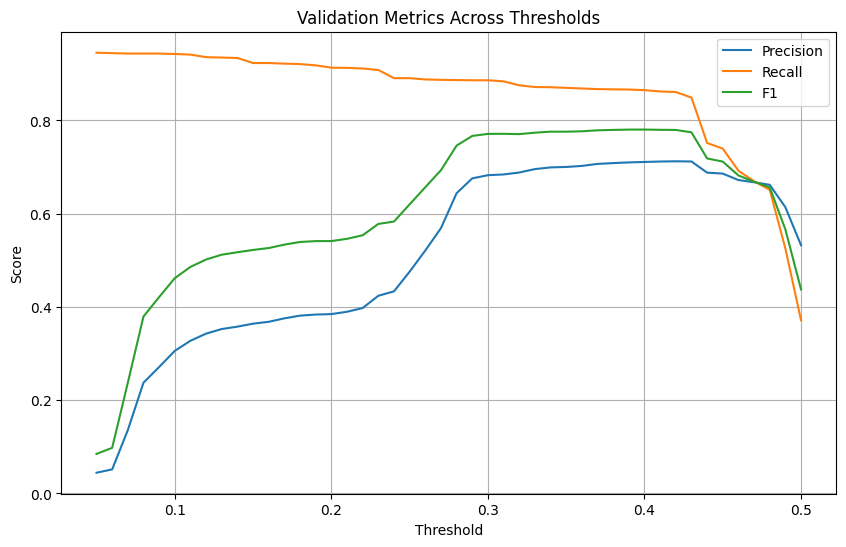

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Metrics Across Thresholds")
plt.legend()
plt.grid(True)
plt.show()

Compute the Precision-Recall AUC — a more informative summary metric than ROC-AUC on imbalanced data.

In [57]:
from sklearn.metrics import precision_recall_curve, auc
precision_vals, recall_vals, _ = precision_recall_curve(y_valid_binary, valid_probs)
pr_auc = auc(recall_vals, precision_vals)

print("Validation PR-AUC:", pr_auc)

Validation PR-AUC: 0.5129542446811337


Plot the Precision-Recall curve.

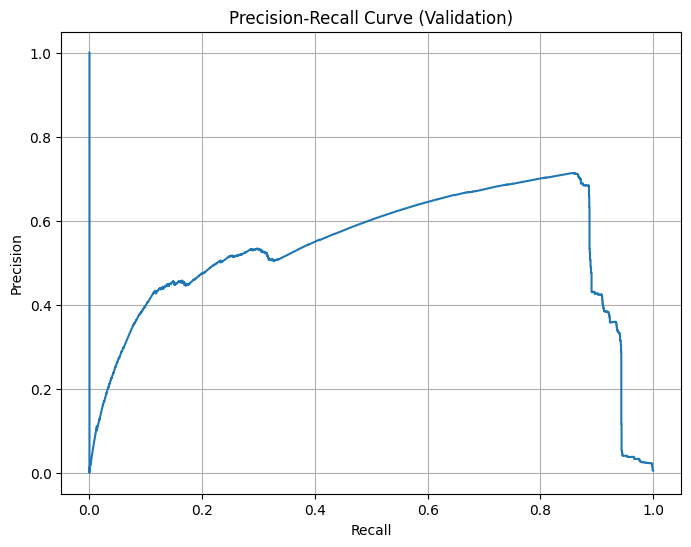

In [58]:
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation)")
plt.grid(True)
plt.show()

Evaluate the SMOTE model on the test set at the chosen threshold (0.40) and print the full classification report.

In [59]:
best_threshold = 0.40

test_probs = rf_improved.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

test_accuracy = accuracy_score(y_test_binary, test_preds)
test_precision = precision_score(y_test_binary, test_preds, zero_division=0)
test_recall = recall_score(y_test_binary, test_preds, zero_division=0)
test_f1 = f1_score(y_test_binary, test_preds, zero_division=0)

print("Improved Random Forest Test Results")
print("-----------------------------------")
print("Threshold :", best_threshold)
print("Accuracy  :", test_accuracy)
print("Precision :", test_precision)
print("Recall    :", test_recall)
print("F1 Score  :", test_f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_test_binary, test_preds))

print("\nClassification Report")
print(classification_report(
    y_test_binary,
    test_preds,
    target_names=["BENIGN", "ATTACK"],
    zero_division=0
))

Improved Random Forest Test Results
-----------------------------------
Threshold : 0.4
Accuracy  : 0.7040121357358143
Precision : 0.9898262335237125
Recall    : 0.28266011046280104
F1 Score  : 0.43974443235322636

Confusion Matrix
[[413094    839]
 [207157  81628]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       0.67      1.00      0.80    413933
      ATTACK       0.99      0.28      0.44    288785

    accuracy                           0.70    702718
   macro avg       0.83      0.64      0.62    702718
weighted avg       0.80      0.70      0.65    702718



Compare validation and test class distributions to confirm they are consistent.

In [60]:
print(y_valid_binary.value_counts(normalize=True))
print(y_test_binary.value_counts(normalize=True))

Label
0    0.995168
1    0.004832
Name: proportion, dtype: float64
Label
0    0.589046
1    0.410954
Name: proportion, dtype: float64


Find the lowest threshold that achieves at least 70% recall on the validation set — useful for setting a minimum-detection-rate constraint.

In [61]:
target_recall = 0.70

best_t = None

for t in thresholds:
    preds = (valid_probs >= t).astype(int)
    rec = recall_score(y_valid_binary, preds)
    
    if rec >= target_recall:
        best_t = t
        break

print("Threshold for recall >= 0.70:", best_t)

Threshold for recall >= 0.70: 0.05


Spot-check precision, recall, and F1 at four fixed thresholds (0.1, 0.2, 0.3, 0.4) on the test set.

In [62]:
for t in [0.1, 0.2, 0.3, 0.4]:
    preds = (test_probs >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_test_binary, preds))
    print("Recall:", recall_score(y_test_binary, preds))
    print("F1:", f1_score(y_test_binary, preds))


Threshold: 0.1
Precision: 0.9777813746119097
Recall: 0.4602108835292692
F1: 0.6258526466481598

Threshold: 0.2
Precision: 0.9770904290136126
Recall: 0.3049742888307911
F1: 0.46485556394191946

Threshold: 0.3
Precision: 0.9884994783268519
Recall: 0.2887061308585972
F1: 0.4468910216037885

Threshold: 0.4
Precision: 0.9898262335237125
Recall: 0.28266011046280104
F1: 0.43974443235322636


Print absolute and relative class counts for all three splits side-by-side.

In [63]:
print("Train distribution")
print(y_train_binary.value_counts())
print(y_train_binary.value_counts(normalize=True))

print("\nValidation distribution")
print(y_valid_binary.value_counts())
print(y_valid_binary.value_counts(normalize=True))

print("\nTest distribution")
print(y_test_binary.value_counts())
print(y_test_binary.value_counts(normalize=True))

Train distribution
Label
0    1400977
1     265555
Name: count, dtype: int64
Label
0    0.840654
1    0.159346
Name: proportion, dtype: float64

Validation distribution
Label
0    456410
1      2216
Name: count, dtype: int64
Label
0    0.995168
1    0.004832
Name: proportion, dtype: float64

Test distribution
Label
0    413933
1    288785
Name: count, dtype: int64
Label
0    0.589046
1    0.410954
Name: proportion, dtype: float64


Check original (non-binary) label distributions on validation and test sets to see how many distinct attack types are present.

In [64]:
print("Validation original label distribution")
print(y_valid.value_counts())

print("\nTest original label distribution")
print(y_test.value_counts())

Validation original label distribution
Label
BENIGN                    456410
WebAttack_BruteForce        1507
WebAttack_XSS                652
Infiltration                  36
WebAttack_SQLInjection        21
Name: count, dtype: int64

Test original label distribution
Label
BENIGN      413933
PortScan    158804
DDoS        128025
Bot           1956
Name: count, dtype: int64


Trying something new.

## Reshuffled Data Splits & Rare Class Consolidation

The existing train/valid/test splits may not be stratified consistently across attack types. This section re-pools all data and creates fresh stratified splits.

In [65]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

print("y_train_binary:", y_train_binary.shape)
print("y_valid_binary:", y_valid_binary.shape)
print("y_test_binary:", y_test_binary.shape)

print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", len(y_train_smote))

X_train: (1666532, 78)
X_valid: (458626, 78)
X_test: (702718, 78)
y_train_binary: (1666532,)
y_valid_binary: (458626,)
y_test_binary: (702718,)
X_train_smote: (2101465, 78)
y_train_smote: 2101465


Extract and rank feature importances from the SMOTE-trained model to understand which features drive predictions.

In [66]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_improved.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance_df.head(20))

                    Feature  Importance
0          Destination Port    0.158333
38        Min Packet Length    0.114894
66   Init_Win_bytes_forward    0.067640
11    Bwd Packet Length Min    0.064841
67  Init_Win_bytes_backward    0.049757
37            Bwd Packets/s    0.039463
7     Fwd Packet Length Min    0.031336
55      Fwd Header Length.1    0.028421
10    Bwd Packet Length Max    0.025188
34        Fwd Header Length    0.025078
54     Avg Bwd Segment Size    0.024587
12   Bwd Packet Length Mean    0.021463
14             Flow Bytes/s    0.019330
6     Fwd Packet Length Max    0.018716
41        Packet Length Std    0.018017
13    Bwd Packet Length Std    0.017585
52      Average Packet Size    0.016672
42   Packet Length Variance    0.016664
40       Packet Length Mean    0.015573
8    Fwd Packet Length Mean    0.014179


Plot the top 20 features by importance as a horizontal bar chart.

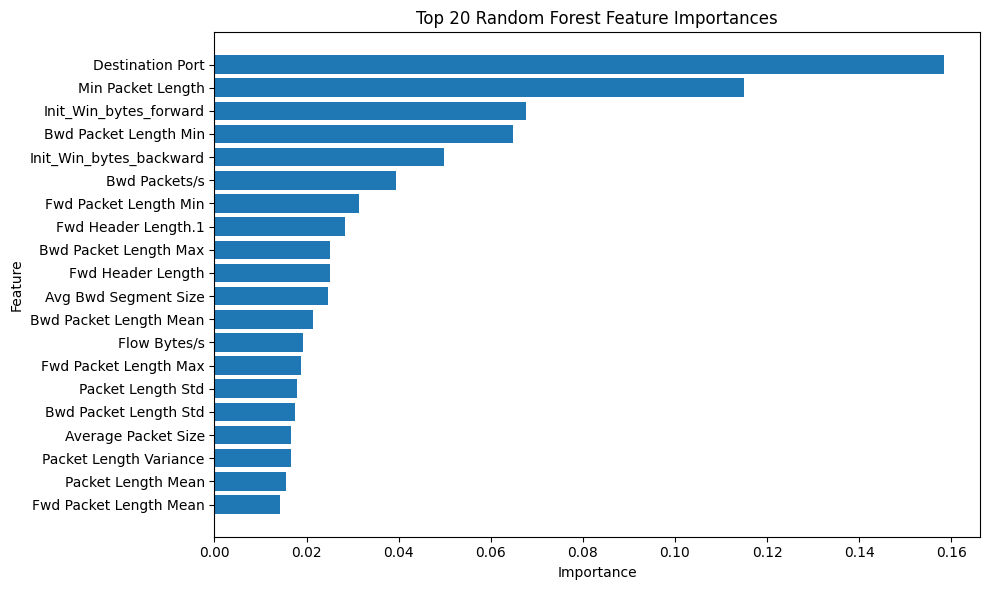

In [67]:
import matplotlib.pyplot as plt

top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

Re-evaluate the SMOTE model on the validation set at the final chosen threshold of 0.40.

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

best_threshold = 0.40

valid_probs = rf_improved.predict_proba(X_valid)[:, 1]
valid_pred = (valid_probs >= best_threshold).astype(int)

print("Validation Confusion Matrix")
print(confusion_matrix(y_valid_binary, valid_pred))

print("\nValidation Classification Report")
print(classification_report(y_valid_binary, valid_pred, target_names=["BENIGN", "ATTACK"], zero_division=0))

print("\nValidation Metrics")
print("Accuracy :", accuracy_score(y_valid_binary, valid_pred))
print("Precision:", precision_score(y_valid_binary, valid_pred, zero_division=0))
print("Recall   :", recall_score(y_valid_binary, valid_pred, zero_division=0))
print("F1 Score :", f1_score(y_valid_binary, valid_pred, zero_division=0))

Validation Confusion Matrix
[[455631    779]
 [   299   1917]]

Validation Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    456410
      ATTACK       0.71      0.87      0.78      2216

    accuracy                           1.00    458626
   macro avg       0.86      0.93      0.89    458626
weighted avg       1.00      1.00      1.00    458626


Validation Metrics
Accuracy : 0.9976495009005159
Precision: 0.711053412462908
Recall   : 0.865072202166065
F1 Score : 0.7805374592833876


Reload all three original parquet splits — these will be re-pooled and re-split from scratch.

In [69]:
import pandas as pd

X_train_old = pd.read_parquet("data/processed/X_train.parquet")
y_train_old = pd.read_parquet("data/processed/y_train.parquet")

X_valid_old = pd.read_parquet("data/processed/X_valid.parquet")
y_valid_old = pd.read_parquet("data/processed/y_valid.parquet")

X_test_old = pd.read_parquet("data/processed/X_test.parquet")
y_test_old = pd.read_parquet("data/processed/y_test.parquet")

Ensure all label arrays are 1D Series.

In [70]:
if isinstance(y_train_old, pd.DataFrame):
    y_train_old = y_train_old.iloc[:, 0]

if isinstance(y_valid_old, pd.DataFrame):
    y_valid_old = y_valid_old.iloc[:, 0]

if isinstance(y_test_old, pd.DataFrame):
    y_test_old = y_test_old.iloc[:, 0]

Concatenate all splits into a single dataset for a clean, stratified re-split.

In [71]:
X = pd.concat([X_train_old, X_valid_old, X_test_old], axis=0).reset_index(drop=True)
y = pd.concat([y_train_old, y_valid_old, y_test_old], axis=0).reset_index(drop=True)

Perform a stratified 60/20/20 train/validation/test split using `train_test_split` twice, preserving the original label distribution in each split.

In [72]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    stratify=y_temp,
    random_state=42
)

Verify the new class distributions across all three splits.

In [73]:
print("Train")
print(y_train.value_counts())

print("\nValidation")
print(y_valid.value_counts())

print("\nTest")
print(y_test.value_counts())

Train
Label
BENIGN                    1453644
DoS Hulk                   147279
PortScan                   101634
DDoS                        81936
DoS GoldenEye                6587
FTP-Patator                  5078
SSH-Patator                  3774
DoS slowloris                3710
DoS Slowhttptest             3519
Bot                          1252
WebAttack_BruteForce          965
WebAttack_XSS                 418
Infiltration                   23
WebAttack_SQLInjection         14
Heartbleed                      7
Name: count, dtype: int64

Validation
Label
BENIGN                    363411
DoS Hulk                   36820
PortScan                   25409
DDoS                       20484
DoS GoldenEye               1647
FTP-Patator                 1270
SSH-Patator                  943
DoS slowloris                927
DoS Slowhttptest             880
Bot                          313
WebAttack_BruteForce         241
WebAttack_XSS                104
Infiltration                   6
WebAt

In [74]:
min_samples = 100

Identify rare attack classes (fewer than 100 training samples) that would be difficult to learn from.

In [75]:
label_counts = y_train.value_counts()

rare_classes = label_counts[label_counts < min_samples].index.tolist()

print("Rare classes:", rare_classes)

Rare classes: ['Infiltration', 'WebAttack_SQLInjection', 'Heartbleed']


Consolidate all rare attack types into a single `OtherAttack` label to prevent them from destabilising training.

In [76]:
y_train = y_train.replace(rare_classes, "OtherAttack")
y_valid = y_valid.replace(rare_classes, "OtherAttack")
y_test  = y_test.replace(rare_classes, "OtherAttack")

In [77]:
print(y_train.value_counts())

Label
BENIGN                  1453644
DoS Hulk                 147279
PortScan                 101634
DDoS                      81936
DoS GoldenEye              6587
FTP-Patator                5078
SSH-Patator                3774
DoS slowloris              3710
DoS Slowhttptest           3519
Bot                        1252
WebAttack_BruteForce        965
WebAttack_XSS               418
OtherAttack                  44
Name: count, dtype: int64


Recompute rare class list after the label consolidation step.

In [78]:
min_samples = 100

label_counts = y_train.value_counts()
rare_classes = label_counts[label_counts < min_samples].index.tolist()

print("Rare classes:", rare_classes)

Rare classes: ['OtherAttack']


Create cleaned label arrays with rare classes merged into `OtherAttack`.

In [79]:
y_train_clean = y_train.replace(rare_classes, "OtherAttack")
y_valid_clean = y_valid.replace(rare_classes, "OtherAttack")
y_test_clean  = y_test.replace(rare_classes, "OtherAttack")

Verify the cleaned label distributions are consistent across all splits.

In [80]:
print("Train")
print(y_train_clean.value_counts())

print("\nValidation")
print(y_valid_clean.value_counts())

print("\nTest")
print(y_test_clean.value_counts())

Train
Label
BENIGN                  1453644
DoS Hulk                 147279
PortScan                 101634
DDoS                      81936
DoS GoldenEye              6587
FTP-Patator                5078
SSH-Patator                3774
DoS slowloris              3710
DoS Slowhttptest           3519
Bot                        1252
WebAttack_BruteForce        965
WebAttack_XSS               418
OtherAttack                  44
Name: count, dtype: int64

Validation
Label
BENIGN                  363411
DoS Hulk                 36820
PortScan                 25409
DDoS                     20484
DoS GoldenEye             1647
FTP-Patator               1270
SSH-Patator                943
DoS slowloris              927
DoS Slowhttptest           880
Bot                        313
WebAttack_BruteForce       241
WebAttack_XSS              104
OtherAttack                 11
Name: count, dtype: int64

Test
Label
BENIGN                  454265
DoS Hulk                 46025
PortScan                 

Derive binary labels from the cleaned multi-class labels.

In [81]:
y_train_binary = (y_train_clean != "BENIGN").astype(int)
y_valid_binary = (y_valid_clean != "BENIGN").astype(int)
y_test_binary  = (y_test_clean != "BENIGN").astype(int)

Confirm binary class counts in each split.

In [82]:
print("Train binary")
print(y_train_binary.value_counts())

print("\nValidation binary")
print(y_valid_binary.value_counts())

print("\nTest binary")
print(y_test_binary.value_counts())

Train binary
Label
0    1453644
1     356196
Name: count, dtype: int64

Validation binary
Label
0    363411
1     89049
Name: count, dtype: int64

Test binary
Label
0    454265
1    111311
Name: count, dtype: int64


## Stage 1: Binary Detection

Train a Random Forest to classify traffic as BENIGN or ATTACK. A tuned class weight and threshold will be used to maximise attack recall without collapsing precision.

In [83]:
from sklearn.ensemble import RandomForestClassifier

rf_binary = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight={0: 1, 1: 8},
    random_state=42,
    n_jobs=-1
)

rf_binary.fit(X_train, y_train_binary)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [84]:
valid_probs = rf_binary.predict_proba(X_valid)[:, 1]

In [85]:
print(valid_probs[:10])

[2.64088177e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
 5.46168577e-06 0.00000000e+00 0.00000000e+00 2.89792650e-05
 6.45443681e-05 0.00000000e+00]


Sweep thresholds 0.05–0.5 on the validation set and collect all metrics.

In [86]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.51, 0.01)

rows = []

for t in thresholds:
    valid_preds = (valid_probs >= t).astype(int)
    
    rows.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_valid_binary, valid_preds),
        "Precision": precision_score(y_valid_binary, valid_preds, zero_division=0),
        "Recall": recall_score(y_valid_binary, valid_preds, zero_division=0),
        "F1": f1_score(y_valid_binary, valid_preds, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)
threshold_df.sort_values("F1", ascending=False).head(10)

,Threshold,Accuracy,Precision,Recall,F1
45,0.50,0.998740,0.994313,0.999315,0.996808
44,0.49,0.998698,0.994091,0.999326,0.996702
43,0.48,0.998599,0.993591,0.999326,0.996450
42,0.47,0.998541,0.993292,0.999337,0.996305
40,0.45,0.998535,0.993159,0.999439,0.996289
41,0.46,0.998532,0.993214,0.999371,0.996283
39,0.44,0.998528,0.993115,0.999450,0.996272
38,0.43,0.998517,0.993049,0.999461,0.996245
37,0.42,0.998499,0.992949,0.999472,0.996200
36,0.41,0.998488,0.992883,0.999483,0.996172


Select the threshold with the highest validation F1.

In [87]:
best_row = threshold_df.sort_values("F1", ascending=False).iloc[0]
best_threshold = best_row["Threshold"]

print("Best threshold:", best_threshold)
print(best_row)

Best threshold: 0.5000000000000001
Threshold    0.500000
Accuracy     0.998740
Precision    0.994313
Recall       0.999315
F1           0.996808
Name: 45, dtype: float64


Plot precision, recall, and F1 vs threshold for Stage 1.

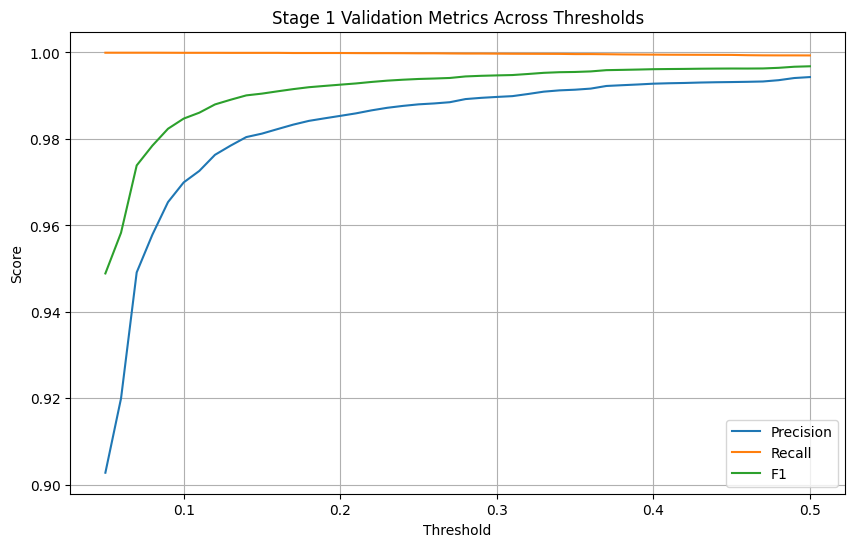

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Stage 1 Validation Metrics Across Thresholds")
plt.legend()
plt.grid(True)
plt.show()

Run Stage 1 inference on the test set using the best validation threshold.

In [89]:
test_probs = rf_binary.predict_proba(X_test)[:, 1]
test_binary_preds = (test_probs >= best_threshold).astype(int)

Print Stage 1 binary classification results on the test set.

In [90]:
from sklearn.metrics import classification_report, confusion_matrix

print("Stage 1: Binary Detection Results")
print("---------------------------------")
print("Threshold :", best_threshold)
print("Accuracy  :", accuracy_score(y_test_binary, test_binary_preds))
print("Precision :", precision_score(y_test_binary, test_binary_preds, zero_division=0))
print("Recall    :", recall_score(y_test_binary, test_binary_preds, zero_division=0))
print("F1 Score  :", f1_score(y_test_binary, test_binary_preds, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_binary, test_binary_preds))

print("\nClassification Report")
print(classification_report(
    y_test_binary,
    test_binary_preds,
    target_names=["BENIGN", "ATTACK"],
    zero_division=0
))

Stage 1: Binary Detection Results
---------------------------------
Threshold : 0.5000000000000001
Accuracy  : 0.9988772508027215
Precision : 0.995052870766313
Recall    : 0.9992633252778252
F1 Score  : 0.9971536534091163

Confusion Matrix
[[453712    553]
 [    82 111229]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    454265
      ATTACK       1.00      1.00      1.00    111311

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576



## Stage 2: Attack Type Classification

For samples flagged as attacks in Stage 1, a second classifier identifies the specific attack category. This two-stage (cascade) design keeps the binary detector focused on sensitivity and the multi-class classifier focused on specificity.

In [91]:
X_train_attack = X_train[y_train_clean != "BENIGN"]
y_train_attack = y_train_clean[y_train_clean != "BENIGN"]

X_valid_attack = X_valid[y_valid_clean != "BENIGN"]
y_valid_attack = y_valid_clean[y_valid_clean != "BENIGN"]

X_test_attack = X_test[y_test_clean != "BENIGN"]
y_test_attack = y_test_clean[y_test_clean != "BENIGN"]

Check how many labelled examples are available per attack type in each split — important for assessing whether multi-class training is feasible.

In [92]:
print("Attack-only train")
print(y_train_attack.value_counts())

print("\nAttack-only validation")
print(y_valid_attack.value_counts())

print("\nAttack-only test")
print(y_test_attack.value_counts())

Attack-only train
Label
DoS Hulk                147279
PortScan                101634
DDoS                     81936
DoS GoldenEye             6587
FTP-Patator               5078
SSH-Patator               3774
DoS slowloris             3710
DoS Slowhttptest          3519
Bot                       1252
WebAttack_BruteForce       965
WebAttack_XSS              418
OtherAttack                 44
Name: count, dtype: int64

Attack-only validation
Label
DoS Hulk                36820
PortScan                25409
DDoS                    20484
DoS GoldenEye            1647
FTP-Patator              1270
SSH-Patator               943
DoS slowloris             927
DoS Slowhttptest          880
Bot                       313
WebAttack_BruteForce      241
WebAttack_XSS             104
OtherAttack                11
Name: count, dtype: int64

Attack-only test
Label
DoS Hulk                46025
PortScan                31761
DDoS                    25605
DoS GoldenEye            2059
FTP-Patator       

Train a balanced multi-class Random Forest on the attack-only training subset.

In [93]:
rf_multiclass = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_multiclass.fit(X_train_attack, y_train_attack)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Evaluate Stage 2 on the attack-only validation subset.

In [94]:
valid_attack_preds = rf_multiclass.predict(X_valid_attack)

print("Stage 2: Validation Attack Labeling")
print("-----------------------------------")
print(classification_report(y_valid_attack, valid_attack_preds, zero_division=0))

Stage 2: Validation Attack Labeling
-----------------------------------
                      precision    recall  f1-score   support

                 Bot       1.00      1.00      1.00       313
                DDoS       1.00      1.00      1.00     20484
       DoS GoldenEye       1.00      1.00      1.00      1647
            DoS Hulk       1.00      1.00      1.00     36820
    DoS Slowhttptest       1.00      0.99      0.99       880
       DoS slowloris       0.99      1.00      0.99       927
         FTP-Patator       1.00      1.00      1.00      1270
         OtherAttack       0.83      0.91      0.87        11
            PortScan       1.00      1.00      1.00     25409
         SSH-Patator       1.00      1.00      1.00       943
WebAttack_BruteForce       0.78      0.72      0.75       241
       WebAttack_XSS       0.46      0.57      0.51       104

            accuracy                           1.00     89049
           macro avg       0.92      0.93      0.93     89

Show the Stage 2 confusion matrix across all attack types on the validation set.

In [95]:
from sklearn.metrics import confusion_matrix

attack_labels = sorted(y_train_attack.unique())
cm_valid_attack = confusion_matrix(y_valid_attack, valid_attack_preds, labels=attack_labels)

cm_valid_attack

array([[  313,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0],
       [    0, 20484,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0],
       [    0,     0,  1643,     4,     0,     0,     0,     0,     0,
            0,     0,     0],
       [    0,     0,     6, 36813,     0,     0,     0,     0,     0,
            0,     1,     0],
       [    0,     0,     0,     0,   872,     7,     0,     0,     0,
            0,     1,     0],
       [    0,     0,     0,     0,     3,   923,     0,     1,     0,
            0,     0,     0],
       [    0,     0,     0,     0,     0,     0,  1268,     0,     0,
            2,     0,     0],
       [    0,     0,     1,     0,     0,     0,     0,    10,     0,
            0,     0,     0],
       [    0,     0,     0,     6,     0,     0,     0,     0, 25398,
            0,     2,     3],
       [    0,     0,     0,     1,     0,     0,     0,     0,     0,
          942,     0

Evaluate Stage 2 on the attack-only test subset.

In [96]:
test_attack_preds = rf_multiclass.predict(X_test_attack)

print("Stage 2: Test Attack Labeling")
print("-----------------------------")
print(classification_report(y_test_attack, test_attack_preds, zero_division=0))

Stage 2: Test Attack Labeling
-----------------------------
                      precision    recall  f1-score   support

                 Bot       1.00      1.00      1.00       391
                DDoS       1.00      1.00      1.00     25605
       DoS GoldenEye       1.00      1.00      1.00      2059
            DoS Hulk       1.00      1.00      1.00     46025
    DoS Slowhttptest       0.99      0.99      0.99      1100
       DoS slowloris       0.99      1.00      1.00      1159
         FTP-Patator       1.00      1.00      1.00      1587
         OtherAttack       0.82      0.69      0.75        13
            PortScan       1.00      1.00      1.00     31761
         SSH-Patator       1.00      1.00      1.00      1180
WebAttack_BruteForce       0.76      0.70      0.73       301
       WebAttack_XSS       0.42      0.51      0.46       130

            accuracy                           1.00    111311
           macro avg       0.91      0.91      0.91    111311
        

## Full Pipeline Inference

Combine Stage 1 and Stage 2: start with all samples labelled BENIGN, then for every sample flagged as an attack by Stage 1 run Stage 2 to assign the specific attack label. Large index arrays are processed in chunks to avoid memory issues.

In [98]:
import numpy as np
import pandas as pd

final_preds = np.array(["BENIGN"] * len(X_test), dtype=object)
attack_idx = np.where(test_binary_preds == 1)[0]

chunk_size = 50000

for start in range(0, len(attack_idx), chunk_size):
    end = start + chunk_size
    chunk_idx = attack_idx[start:end]
    
    X_chunk = X_test.iloc[chunk_idx]
    chunk_preds = rf_multiclass.predict(X_chunk)
    
    final_preds[chunk_idx] = chunk_preds

final_preds = pd.Series(final_preds, index=X_test.index, name="PredictedLabel")

Print the end-to-end classification report comparing final predicted labels against ground truth across all classes.

In [99]:
from sklearn.metrics import classification_report

print("Full Pipeline Test Results")
print("--------------------------")
print(classification_report(y_test_clean, final_preds, zero_division=0))

Full Pipeline Test Results
--------------------------
                      precision    recall  f1-score   support

              BENIGN       1.00      1.00      1.00    454265
                 Bot       0.70      0.88      0.78       391
                DDoS       1.00      1.00      1.00     25605
       DoS GoldenEye       0.99      0.99      0.99      2059
            DoS Hulk       1.00      1.00      1.00     46025
    DoS Slowhttptest       0.99      0.99      0.99      1100
       DoS slowloris       1.00      1.00      1.00      1159
         FTP-Patator       1.00      1.00      1.00      1587
         OtherAttack       0.78      0.54      0.64        13
            PortScan       0.99      1.00      1.00     31761
         SSH-Patator       1.00      1.00      1.00      1180
WebAttack_BruteForce       0.77      0.70      0.73       301
       WebAttack_XSS       0.42      0.51      0.46       130

            accuracy                           1.00    565576
           mac

Show the predicted label distribution across the full test set.

In [100]:
print(final_preds.value_counts())

PredictedLabel
BENIGN                  453794
DoS Hulk                 46233
PortScan                 31934
DDoS                     25597
DoS GoldenEye             2056
FTP-Patator               1585
SSH-Patator               1181
DoS slowloris             1159
DoS Slowhttptest          1103
Bot                        493
WebAttack_BruteForce       273
WebAttack_XSS              159
OtherAttack                  9
Name: count, dtype: int64


Cross-tabulate true vs predicted labels (full confusion matrix across all attack types and BENIGN).

In [101]:
print(pd.crosstab(y_test, final_preds))

PredictedLabel        BENIGN  Bot   DDoS  DoS GoldenEye  DoS Hulk  \
Label                                                               
BENIGN                453712  147      4              4       204   
Bot                       45  346      0              0         0   
DDoS                       9    0  25593              0         2   
DoS GoldenEye              6    0      0           2045         4   
DoS Hulk                   4    0      0              6     46014   
DoS Slowhttptest           4    0      0              1         0   
DoS slowloris              1    0      0              0         0   
FTP-Patator                0    0      0              0         0   
OtherAttack                6    0      0              0         0   
PortScan                   2    0      0              0         8   
SSH-Patator                2    0      0              0         0   
WebAttack_BruteForce       2    0      0              0         0   
WebAttack_XSS              1    0 

Compute the overall attack detection rate: what fraction of true attacks were caught by the full pipeline.

In [105]:
total_attacks = (y_test != "BENIGN").sum()
missed_attacks = ((y_test != "BENIGN") & (final_preds == "BENIGN")).sum()
attack_detection_rate = 1 - (missed_attacks / total_attacks)

print("Total attacks:", total_attacks)
print("Missed attacks:", missed_attacks)
print("Attack detection rate:", attack_detection_rate)
print("Miss rate (%):", (missed_attacks / total_attacks) * 100)

Total attacks: 111311
Missed attacks: 82
Attack detection rate: 0.9992633252778252
Miss rate (%): 0.07366747221748075


Export the per-class metrics from the full pipeline as a DataFrame for easier inspection or saving.

In [106]:
report = classification_report(
    y_test,
    final_preds,
    output_dict=True,
    zero_division=0
)

import pandas as pd
report_df = pd.DataFrame(report).transpose()

print(report_df)

                      precision    recall  f1-score        support
BENIGN                 0.999819  0.998783  0.999301  454265.000000
Bot                    0.701826  0.884910  0.782805     391.000000
DDoS                   0.999844  0.999531  0.999688   25605.000000
DoS GoldenEye          0.994650  0.993201  0.993925    2059.000000
DoS Hulk               0.995263  0.999761  0.997507   46025.000000
DoS Slowhttptest       0.987307  0.990000  0.988652    1100.000000
DoS slowloris          0.995686  0.995686  0.995686    1159.000000
FTP-Patator            1.000000  0.998740  0.999369    1587.000000
OtherAttack            0.777778  0.538462  0.636364      13.000000
PortScan               0.994175  0.999591  0.996876   31761.000000
SSH-Patator            0.997460  0.998305  0.997882    1180.000000
WebAttack_BruteForce   0.769231  0.697674  0.731707     301.000000
WebAttack_XSS          0.415094  0.507692  0.456747     130.000000
accuracy               0.998534  0.998534  0.998534       0.99

## Conclusion

This notebook explored iterative improvements to a binary network intrusion detection model.

**What was tried:**

1. **Threshold tuning on the original model** — lowering the decision threshold from 0.5 improved attack recall but precision suffered, and gains were limited by the model itself.
2. **Retraining with class balancing** — a downsampled 2:1 BENIGN/ATTACK ratio combined with `class_weight="balanced"` produced a more attack-aware model.
3. **Multi-classifier comparison** — six classifiers were benchmarked with per-model threshold optimisation; Random Forest consistently ranked near the top.
4. **SMOTE oversampling** — synthetic minority samples improved generalisation to attacks, with PR-AUC used as the primary metric given the class imbalance.
5. **Reshuffled stratified splits** — re-pooling and re-splitting ensured consistent attack-type proportions across splits, with rare classes consolidated into `OtherAttack`.
6. **Two-stage cascade pipeline** — Stage 1 optimised for high recall; Stage 2 added multi-class attack labelling for flagged traffic.

**Final pipeline performance** is summarised by the end-to-end classification report and attack detection rate — the fraction of true attacks caught, which is the most operationally meaningful metric in an intrusion detection context.

**Key takeaway:** The largest gains came from combining SMOTE, class weighting, and threshold tuning together, and splitting the problem into two focused classifiers rather than asking one model to do everything.